# Modelagem — Credit Card Default

## Contexto de Negócio

Este notebook constrói um modelo preditivo de inadimplência orientado a um **banco real**.

Em um contexto de concessão de crédito, os dois tipos de erro têm custos **assimétricos**:

| Erro | Situação | Consequência |
|------|----------|--------------|
| **Falso Negativo (FN)** | Modelo aprova → cliente dá calote | Prejuízo real de capital |
| **Falso Positivo (FP)** | Modelo recusa → cliente pagaria | Receita perdida (custo de oportunidade) |

> Um empréstimo não pago custa tipicamente **5x a 20x** mais do que recusar um bom pagador.  
> Por isso, o modelo é calibrado para **maximizar Recall** (capturar o máximo de inadimplentes),  
> aceitando um nível controlado de Falsos Positivos em troca.

---

### Interesses do modelo
| Aspecto | Modelo de Negócio |
|---------|-------------------|
| `scale_pos_weight` | **10** (simula calote 10× mais caro) |
| Threshold |  **Meta: Recall ≥ 0.80** |
| Métrica principal |  **Recall da classe 1** |
| Cenários avaliados | **3 cenários de conservadorismo** |


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import sys
sys.path.append('../src')

from preprocessing import rename_columns, transform_variables, clean_data, process_status
from features import feature_engineering
from modeling import threshold_para_recall
from sklearn.model_selection import train_test_split

# Pipeline de preparo dos dados
df_raw = pd.read_csv('../data/credit.csv')
df = (df_raw
      .pipe(rename_columns)
      .drop(df_raw.index[0])
      .pipe(transform_variables)
      .pipe(clean_data)
      .pipe(process_status)
      .pipe(feature_engineering))

X = df.drop(columns=['id', 'default'])
y = df['default']

#stratify=y garante a mesma proporção de default nos dois conjuntos
#Necessário pois o dataset é desbalanceado (~22% default)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Treino: {X_train.shape} | Teste: {X_test.shape}")
print(f"Default no treino: {y_train.mean():.2%} | no teste: {y_test.mean():.2%}")


Treino: (21000, 30) | Teste: (9000, 30)
Default no treino: 22.12% | no teste: 22.12%


In [3]:
df.head()

,id,limit_bal,sex,education,marriage,age,pay_1,pay_2,pay_3,pay_4,...,pay_amt5,pay_amt6,default,avg_bill,util_ratio,pay_ratio_1,pay_ratio_2,pay_ratio_3,n_delays,max_delay
1,1,20000,2,2,1,24,2,2,0,0,...,0,0,1,1284.000000,0.064197,0.000000,0.998551,0.000000,2,2
2,2,120000,2,2,2,26,0,2,0,0,...,0,2000,1,2846.166667,0.023718,0.000000,0.372717,0.305530,2,2
3,3,90000,2,2,2,34,0,0,0,0,...,1000,5000,0,16942.166667,0.188244,0.108212,0.110619,0.069774,0,0
4,4,50000,2,2,1,37,0,0,0,0,...,1069,1000,0,38555.666667,0.771098,0.041465,0.040960,0.042380,0,0
5,5,50000,1,2,1,57,0,0,0,0,...,689,679,0,18223.166667,0.364456,0.352671,1.023580,0.477532,0,0


## 1. Treinamento do Modelo

In [4]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score, average_precision_score,
    precision_recall_curve, RocCurveDisplay, PrecisionRecallDisplay,
    confusion_matrix
)
from imblearn.pipeline import Pipeline

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

print(f"Classe 0 (adimplente):   {neg:,}")
print(f"Classe 1 (inadimplente): {pos:,}")
print(f"Razão natural (neg/pos): {neg/pos:.2f}")
print(f"scale_pos_weight negócio: 10  (simula calote 10× mais caro que recusa)")

# ── MUDANÇA: scale_pos_weight = 10 em vez de neg/pos ≈ 3.44 ─────────────────
# Justificativa: em crédito real, um calote implica perda de todo o principal
# emprestado + custos de cobrança + provisão regulatória. Uma recusa indevida
# implica apenas perda da margem de juros. A proporção 10:1 é conservadora
# e amplamente usada em scorecards de concessão.
xgb = XGBClassifier(
    n_estimators=300,        #Quantidade de árvores construídas
    learning_rate=0.05,      #Peso de aprendizado dado a cada árvore
    max_depth=5,             #Nível de profundidade das árvores
    subsample=0.8,           #Usa 80% das amostras aleatoriamente (generalização)
    colsample_bytree=0.8,    #Usa 80% das features por árvore (generalização)
    scale_pos_weight=10,     #Dá o peso de 10x mais para a target
    eval_metric='aucpr',     #Otimiza PR-AUC internamente
    random_state=42,
    n_jobs=-1
)

pipe = Pipeline([('xgb', xgb)])
pipe.fit(X_train, y_train)
print("\nModelo treinado ✓")


Classe 0 (adimplente):   16,355
Classe 1 (inadimplente): 4,645
Razão natural (neg/pos): 3.52
scale_pos_weight negócio: 10  (simula calote 10× mais caro que recusa)

Modelo treinado ✓


In [5]:
# Probabilidades brutas — usaremos para threshold tuning
y_proba = pipe.predict_proba(X_test)[:, 1] 

# Predição padrão com threshold 0.5 (referência)
y_pred_050 = (y_proba >= 0.50).astype(int)


## 2. Métricas Base (threshold 0.5)

Avaliação inicial com threshold padrão — serve como referência para comparação com os cenários de negócio.


In [6]:
roc_auc = roc_auc_score(y_test, y_proba)
pr_auc  = average_precision_score(y_test, y_proba)

print("=" * 55)
print("CLASSIFICATION REPORT — Threshold 0.50 (referência)")
print("=" * 55)
print(classification_report(y_test, y_pred_050, target_names=['Adimplente', 'Inadimplente']))
print(f"ROC-AUC : {roc_auc:.4f}  ← separação geral das classes")
print(f"PR-AUC  : {pr_auc:.4f}  ← métrica principal para dados desbalanceados")


CLASSIFICATION REPORT — Threshold 0.50 (referência)
              precision    recall  f1-score   support

  Adimplente       0.91      0.48      0.63      7009
Inadimplente       0.31      0.84      0.46      1991

    accuracy                           0.56      9000
   macro avg       0.61      0.66      0.54      9000
weighted avg       0.78      0.56      0.59      9000

ROC-AUC : 0.7704  ← separação geral das classes
PR-AUC  : 0.5493  ← métrica principal para dados desbalanceados


## 3. Threshold Orientado a Negócio

### Por que não usar threshold 0.5?

O threshold padrão maximiza acurácia geral — que num dataset com 78% de adimplentes  
já é alta mesmo classificando tudo como adimplente. Para negócio, a pergunta é outra:

> *"A partir de qual probabilidade de dívida devemos recusar o crédito?"*

A resposta depende da **meta de Recall** definida pelo banco:  
quanto do total de inadimplentes reais o banco precisa capturar?

Abaixo simulamos três perfis conservadores e identificamos o threshold de cada um.


In [7]:

precision_arr, recall_arr, thresholds = precision_recall_curve(y_test, y_proba) # Encontrados melhores valores dentro de modeling.py

# Cenário 1: Banco moderado — captura 75% dos inadimplentes
# Cenário 2: Banco conservador — captura 80% dos inadimplentes
# Cenário 3: Banco muito conservador — captura 90% dos inadimplentes
# Criado um dicionário que leva os valores escolhidos para Threshold
cenarios = {
    'Moderado   (Recall ≥ 75%)': 0.75,
    'Conservador (Recall ≥ 80%)': 0.80,
    'Muito conservador (Recall ≥ 90%)': 0.90, 
}  

resultados = {}
print(f"{'Cenário':<38} {'Threshold':>10} {'Recall':>8} {'Precision':>10} {'F1':>8}")
print("-" * 78)

for nome, meta in cenarios.items(): # Valores dentro do dicionário
    thr, r, p = threshold_para_recall(meta, precision_arr, recall_arr, thresholds) #Chama a função utilizando das metas em 'cenarios' para chegarem ao threshold definido
    if thr is not None:
        f1 = 2 * r * p / (r + p)
        resultados[nome] = {'thr': thr, 'recall': r, 'precision': p, 'f1': f1,
                             'pred': (y_proba >= thr).astype(int)}
        print(f"{nome:<38} {thr:>10.3f} {r:>8.3f} {p:>10.3f} {f1:>8.3f}")

# Threshold F1-ótimo
f1_scores = 2 * (precision_arr * recall_arr) / (precision_arr + recall_arr + 1e-9) #'1e-9' valor extremamente baixo para impedir divisão com 0
best_idx  = f1_scores.argmax()
best_thr  = thresholds[best_idx]
y_pred_f1 = (y_proba >= best_thr).astype(int)
print(f"\n{'Referência (F1 ótimo)':<38} {best_thr:>10.3f} "
      f"{recall_arr[best_idx]:>8.3f} {precision_arr[best_idx]:>10.3f} "
      f"{f1_scores[best_idx]:>8.3f}")


Cenário                                 Threshold   Recall  Precision       F1
------------------------------------------------------------------------------
Moderado   (Recall ≥ 75%)                   0.601    0.752      0.368    0.494
Conservador (Recall ≥ 80%)                  0.549    0.802      0.337    0.475
Muito conservador (Recall ≥ 90%)            0.410    0.900      0.283    0.431

Referência (F1 ótimo)                       0.756    0.582      0.502    0.539


## 4. Análise de Custo por Cenário

Aqui traduzimos os erros do modelo em **impacto financeiro estimado**.

Premissas simplificadas (ajustáveis conforme dados reais do banco):
- Valor médio emprestado por cliente: **NT$ 50.000**
- Taxa de recuperação em caso de calote: **20%** (banco recupera 20% via cobrança)
- Receita média de juros perdida por recusa indevida: **NT$ 2.500**


In [8]:
# ── Premissas financeiras (ajustar com dados reais) ──────────────────────────
VALOR_MEDIO_EMPRESTIMO = 50_000   # NT$
TAXA_RECUPERACAO       = 0.20     # 20% recuperado em cobrança
RECEITA_POR_RECUSA     = 2_500    # NT$ de juros perdidos por FP

custo_fn = VALOR_MEDIO_EMPRESTIMO * (1 - TAXA_RECUPERACAO)  # = 40.000 NT$
custo_fp = RECEITA_POR_RECUSA                                # =  2.500 NT$

print(f"Custo por Falso Negativo (calote não detectado): NT$ {custo_fn:,.0f}")
print(f"Custo por Falso Positivo (bom cliente recusado): NT$ {custo_fp:,.0f}")
print(f"Proporção de custo FN/FP: {custo_fn/custo_fp:.1f}×\n")

# Adiciona referência acadêmica à análise
todos_cenarios = {
    'Ref. acadêmica (F1 ótimo)': {
        'thr': best_thr, 'pred': y_pred_f1
    },
    **{k: {'thr': v['thr'], 'pred': v['pred']} for k, v in resultados.items()}
}

print(f"{'Cenário':<38} {'FN':>6} {'FP':>6} {'Custo FN (NT$)':>16} {'Custo FP (NT$)':>16} {'Custo Total':>14}")
print("-" * 100)

for nome, dados in todos_cenarios.items():
    tn, fp, fn, tp = confusion_matrix(y_test, dados['pred']).ravel()
    c_fn   = fn * custo_fn
    c_fp   = fp * custo_fp
    total  = c_fn + c_fp
    print(f"{nome:<38} {fn:>6,} {fp:>6,} {c_fn:>16,.0f} {c_fp:>16,.0f} {total:>14,.0f}")

print("\n→ O cenário com menor custo total é o recomendado para implantação.")


Custo por Falso Negativo (calote não detectado): NT$ 40,000
Custo por Falso Positivo (bom cliente recusado): NT$ 2,500
Proporção de custo FN/FP: 16.0×

Cenário                                    FN     FP   Custo FN (NT$)   Custo FP (NT$)    Custo Total
----------------------------------------------------------------------------------------------------
Ref. acadêmica (F1 ótimo)                 833  1,149       33,320,000        2,872,500     36,192,500
Moderado   (Recall ≥ 75%)                 494  2,570       19,760,000        6,425,000     26,185,000
Conservador (Recall ≥ 80%)                394  3,139       15,760,000        7,847,500     23,607,500
Muito conservador (Recall ≥ 90%)          199  4,538        7,960,000       11,345,000     19,305,000

→ O cenário com menor custo total é o recomendado para implantação.


## 5. Curvas ROC e Precision-Recall

As curvas mostram o comportamento do modelo ao longo de todos os possíveis thresholds.  
Os pontos marcados indicam onde cada cenário de negócio se posiciona.


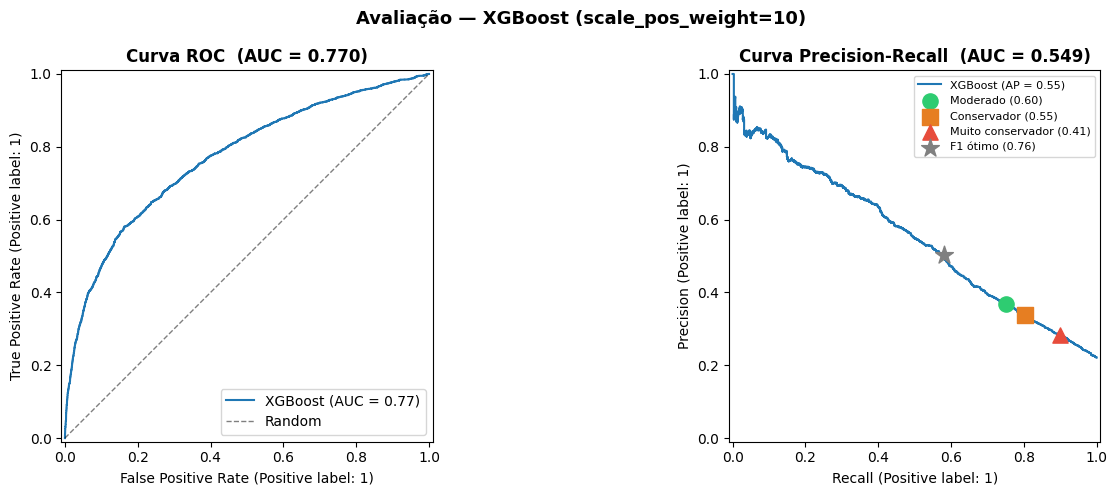

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Curva ROC ────────────────────────────────────────────────────────────────
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[0], name='XGBoost')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random', alpha=0.5)
axes[0].set_title(f'Curva ROC  (AUC = {roc_auc:.3f})', fontweight='bold')
axes[0].legend(loc='lower right')

# ── Curva PR com pontos de cada cenário ──────────────────────────────────────
PrecisionRecallDisplay.from_predictions(y_test, y_proba, ax=axes[1], name='XGBoost')

cores   = ['#2ecc71', '#e67e22', '#e74c3c']
markers = ['o', 's', '^']

for (nome, dados), cor, marker in zip(resultados.items(), cores, markers):
    r = dados['recall']
    p = dados['precision']
    axes[1].scatter(r, p, color=cor, marker=marker, s=120, zorder=5,
                    label=f"{nome.split('(')[0].strip()} ({dados['thr']:.2f})")

# Ponto acadêmico
axes[1].scatter(recall_arr[best_idx], precision_arr[best_idx],
                color='gray', marker='*', s=180, zorder=5,
                label=f'F1 ótimo ({best_thr:.2f})')

axes[1].set_title(f'Curva Precision-Recall  (AUC = {pr_auc:.3f})', fontweight='bold')
axes[1].legend(fontsize=8, loc='upper right')

fig.suptitle('Avaliação — XGBoost (scale_pos_weight=10)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/roc_pr_curves.png', bbox_inches='tight')
plt.show()


## 6. Matrizes de Confusão — Comparação de Cenários

Comparação visual dos quatro cenários: referência acadêmica e os três perfis de negócio.


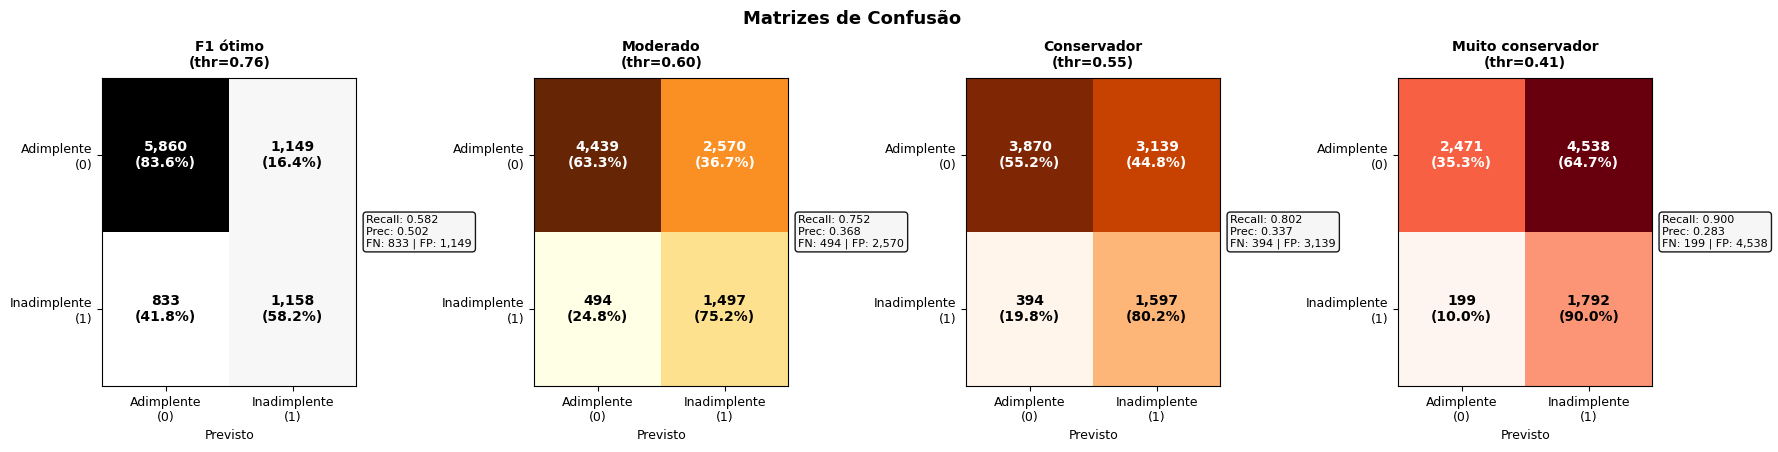

In [10]:
def plot_confusion(y_true, y_pred, titulo, ax, cmap='Blues'):
    cm     = confusion_matrix(y_true, y_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100 # Pega a pocentagem dos valores dentro da matriz. 'keepdims=True' garante a utilização de todos
    labels = ['Adimplente\n(0)', 'Inadimplente\n(1)']

    ax.imshow(cm, interpolation='nearest', cmap=cmap, aspect='auto')
    thresh = cm.max() / 2
    for i in range(2):
        for j in range(2):
            cor = 'white' if cm[i, j] > thresh else 'black'
            ax.text(j, i, f'{cm[i, j]:,}\n({cm_pct[i, j]:.1f}%)',
                    ha='center', va='center', fontsize=10, fontweight='bold', color=cor)

    tn, fp, fn, tp = cm.ravel()
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel('Previsto', fontsize=9)
    ax.set_title(titulo, fontsize=10, fontweight='bold', pad=8)

    info = f'Recall: {tp/(tp+fn):.3f}\nPrec: {tp/(tp+fp):.3f}\nFN: {fn:,} | FP: {fp:,}'
    ax.text(1.04, 0.5, info, transform=ax.transAxes, fontsize=8,
            va='center', ha='left',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#f5f5f5', alpha=0.9))

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.subplots_adjust(wspace=0.7)

cmaps = ['Greys', 'YlOrBr', 'Oranges', 'Reds']
titulos = [
    f'F1 ótimo\n(thr={best_thr:.2f})',
    f'Moderado\n(thr={resultados["Moderado   (Recall ≥ 75%)"]["thr"]:.2f})',
    f'Conservador\n(thr={resultados["Conservador (Recall ≥ 80%)"]["thr"]:.2f})',
    f'Muito conservador\n(thr={resultados["Muito conservador (Recall ≥ 90%)"]["thr"]:.2f})',
]
preds = [
    y_pred_f1,
    resultados['Moderado   (Recall ≥ 75%)']['pred'],
    resultados['Conservador (Recall ≥ 80%)']['pred'],
    resultados['Muito conservador (Recall ≥ 90%)']['pred'],
]

for ax, titulo, pred, cmap in zip(axes, titulos, preds, cmaps):
    plot_confusion(y_test, pred, titulo, ax, cmap=cmap)

fig.suptitle('Matrizes de Confusão',
             fontsize=13, fontweight='bold', y=1.05)

plt.savefig('../plots/confusion_matrix_business.png', bbox_inches='tight')
plt.show()


## 7. Explicabilidade — SHAP

Em um banco real, o modelo precisa ser **explicável**: reguladores e o comitê de crédito  
exigem justificativas para cada recusa. O SHAP responde exatamente a isso.

- **Summary plot:** quais features mais influenciam o modelo globalmente
- **Waterfall plot:** por que *este* cliente específico foi classificado como risco


c:\Users\André\Documents\credit_risk\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Importância global das features (SHAP Summary Plot):


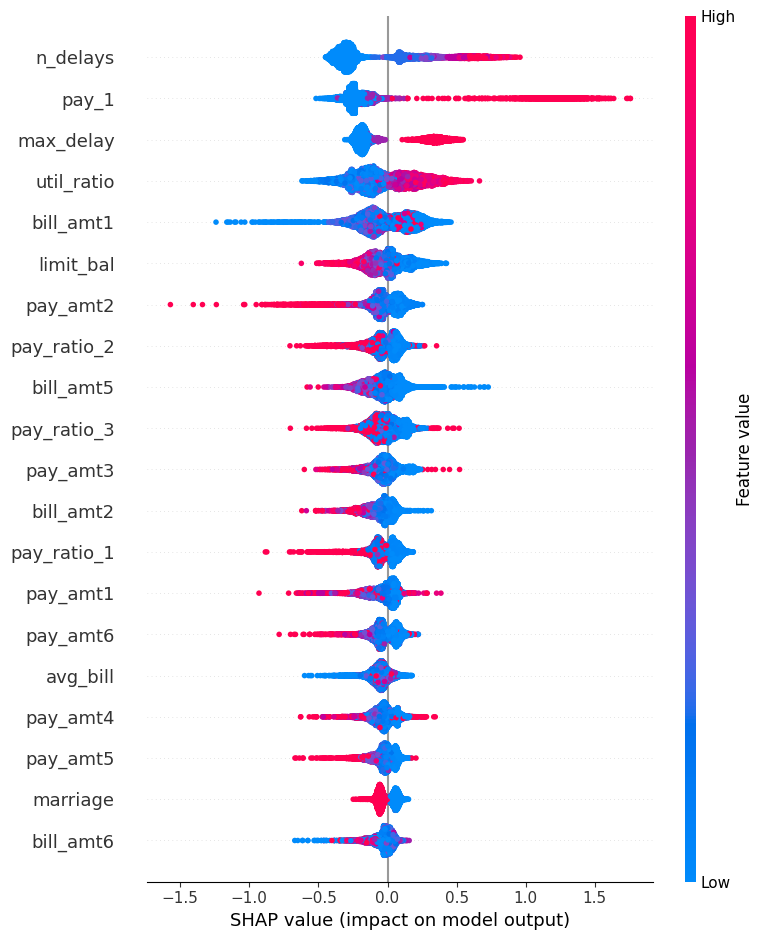


Cliente #3
  Probabilidade de default prevista: 0.919
  Situação real: ADIMPLENTE

Waterfall — contribuição de cada feature para este cliente:


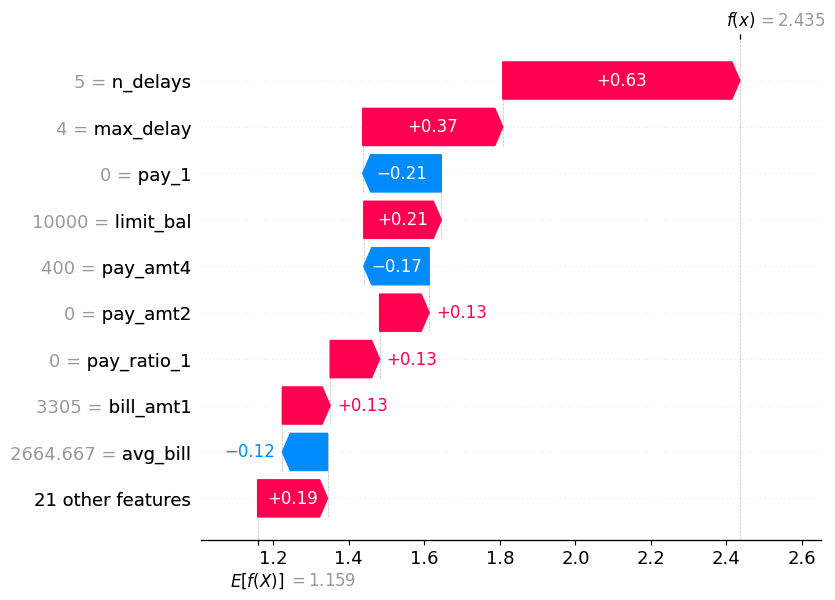

O cliente na posição 3 tem o ID real: 16104


In [11]:
import shap

explainer   = shap.TreeExplainer(pipe['xgb'])
shap_values = explainer.shap_values(X_test)

# ── Importância global ────────────────────────────────────────────────────────
# Cada ponto é um cliente. Vermelho = valor alto da feature, azul = valor baixo.
# Posição no eixo X = quanto empurra o modelo para default (direita) ou não (esquerda).
print("Importância global das features (SHAP Summary Plot):")
shap.summary_plot(shap_values, X_test, feature_names=X.columns.tolist())

# ── Explicação individual ─────────────────────────────────────────────────────
id_cliente = 3
prob_cliente = y_proba[id_cliente]
real_cliente = y_test.iloc[id_cliente]

print(f"\nCliente #{id_cliente}")
print(f"  Probabilidade de default prevista: {prob_cliente:.3f}")
print(f"  Situação real: {'INADIMPLENTE' if real_cliente == 1 else 'ADIMPLENTE'}")
print("\nWaterfall — contribuição de cada feature para este cliente:")

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[id_cliente],
        base_values=explainer.expected_value,
        data=X_test.iloc[id_cliente],
        feature_names=X.columns.tolist()
    )
)

# Resgata o ID real que está no índice do X_test
id_real = X_test.index[id_cliente]

print(f"O cliente na posição {id_cliente} tem o ID real: {id_real}")

In [12]:
dados_do_cliente = df.loc[id_real]
display(dados_do_cliente.to_frame().T)

,id,limit_bal,sex,education,marriage,age,pay_1,pay_2,pay_3,pay_4,...,pay_amt5,pay_amt6,default,avg_bill,util_ratio,pay_ratio_1,pay_ratio_2,pay_ratio_3,n_delays,max_delay
16104,16104,10000,2,2,1,37,0,4,3,2,...,0,36,0,2664.666667,0.26644,0.0,0.0,0.199124,5,4


## 8. Recomendação Final

### Qual cenário usar?

A resposta depende da política de risco do banco. A decisão será tomada baseado no
quanto de risco o banco escolherá assumir ao emprestar dinheiro aos clientes

Como referência prática:

| Perfil do banco | Cenário recomendado | Justificativa |
|----------------|--------------------|-|
| Banco de varejo com margem apertada | Conservador (Recall ≥ 80%) | Equilibra captura e falsos alarmes |
| Banco com histórico de inadimplência alto | Muito conservador (Recall ≥ 90%) | Prioriza capital acima de tudo |
| Fintech com apetite de risco | Moderado (Recall ≥ 75%) | Aceita mais risco para crescer carteira |



In [13]:
import joblib
import os

# O exist_ok=True evita erros caso a pasta já exista
os.makedirs('../models', exist_ok=True)

path = '../models/xgb_credit_model.pkl'
joblib.dump(pipe, path)

print(f"✅ Modelo salvo em: {path}")

✅ Modelo salvo em: ../models/xgb_credit_model.pkl
